<div style="display:none">
$$
\newcommand{\rvar}[1]{\mathrm{#1}}
\newcommand{\rvec}[1]{\mathbf{#1}}
\newcommand{\vec}[1]{\pmb{#1}}
\newcommand{\tens}[1]{\pmb{\mathsf{#1}}}
\newcommand{\tensel}[1]{\mathsf{#1}}
\newcommand{\st}[1]{\mathcal{#1}}
\newcommand{\diag}[1]{\mathrm{diag}(\vec{#1})}
$$
</div>

In [1]:
# Setup for Google Colab
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('dl_course'):
        !git clone -q --depth 1 https://github.com/konstantin-schekotihin/dl_course.git
    %cd -q /content/dl_course/02_ML
    !pip install -q torch-geometric wandb

# some initialization stuff
%run ../init.py
%matplotlib inline

import nns.helpers as hp

<IPython.core.display.Latex object>

# Connectionist models

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/neuron.jpg" width="40%"/>
</center>
<p style="text-align:right">Copyright [AI:MA]</p>

+ Human neuron switching time ~$.001$ second
+ Number of neurons ~$10^{10}$
+ Connections per neuron ~$10^{4-5}$
+ Scene recognition time ~$.1$ second
+ 100 inference steps doesn't seem like enough
+ [$\rightarrow$] much parallel computation

# Artificial neural networks

## Properties of Artificial Neural Nets (ANN's)

- Many neuron-like threshold switching units
- Many weighted interconnections among units
- Highly parallel, distributed processing
- Emphasis on automatic feature selection 

## When to consider ANNs
- Input is high-dimensional discrete or real-valued (e.g. raw sensor input)
- Output is discrete or real valued
- Output is a vector of values
- Possibly noisy data
- Form of the target function is unknown 
- Human-readability/explainability of a model/results is unimportant

## Perceptron

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-perceptron.jpg" width="50%"/>
</center>

- $w_0$ represents bias of the model - a threshold that the weighted combination of inputs should surpass in order for the perceptron to output a 1.
- The activation function is often called unit step function, Heaviside step function, or *hardlim*
- Often a vector notation is used, where $\vec{w}$ is a column and $\vec{x}$ is a row vector
$$\hat{y} = \left\{ \begin{array}{rl}
      1 & \mbox{if $\vec{x}^\top\vec{w} > 0$}\\
     -1 & \mbox{otherwise}  
\end{array}
\right. $$
- or simply $\hat{y} = \mathit{hardlim}(\vec{x}^\top\vec{w})$

## Training a Perceptron

- Given a set of examples $\vec{X}$, their labels $\vec{t}=[t_1, t_2, \dots, t_m]^\top$ and a learning rate $\eta \leq 1$

$$ \vec{X} = \left[ \begin{array}{cccc}
1 & x_{11} & \dots & x_{1n} \\
1 & x_{21} & \dots & x_{1n}  \\
\dots & \dots & \dots & \dots  \\
1 & x_{m1} & \dots & x_{mn} \\
\end{array} \right] 
=
\left[ \begin{array}{c}
\vec{x}_1  \\
\vec{x}_2 \\
\dots  \\
\vec{x}_m  \\
\end{array} \right]
$$

- Initialize the weight vector $\vec{w}$ with some small randomly generated values
- Present each example $\vec{x}_k \in \vec{X}$ to the network, i.e., compute a vector $\vec{\hat{y}} = [\hat{y}_1, \dots, \hat{y}_m]^\top$, where $\hat{y}_k = \mathit{hardlim}(\vec{x}_k\vec{w})$
    - Intuitively:
      - If the example is classified correctly, then $t_{k} - \hat{y}_k = 0$ and therefore no weights must be updated
      - Otherwise $t_{k} - \hat{y}_k = \pm 2$, therefore, each weight $w_i$ must be updated, i.e., increased/decreased by $\eta\:\sum_{k=0}^m x_{ki}$
- Update the weights:
$$\vec{w}_{new} = \vec{w}_{old} + \eta\; \Delta\vec{w} \quad\text{  where  }\quad \Delta\vec{w} = (\vec{t}-\vec{\hat{y}})\;\vec{X}$$
   - that is 
$$\Delta w_{i} = \sum_{\langle \vec{x}_k, t_k, \hat{y}_k \rangle \in \langle \vec{X}, \vec{t}, \vec{\hat{y}} \rangle} (t_{k} - \hat{y}_k) x_{ki}$$
where $x_{ki} \in \vec{x}_k$ is the observed value of an $i$-th feature in $k$-th example

In [2]:
class Perceptron:

    def __init__(self, h=0.01, epoch=1000, eps = 0.0001):
        self.h = h
        self.epoch = epoch
        self.eps = eps

    def _fit(self, X, labels):
        for i in range(self.epoch):
            # forward - compute predictions
            y_hat = self._predict(X)
            # compare labels - error vector
            err = torch.subtract(labels, y_hat)
            # termination criterion
            if (torch.norm(err) < self.eps): break
            # update the weights
            dw = torch.matmul(err, X).reshape(-1,1)
            self.w += self.h*dw

        print("Epoch {}: y_hat={}, err={}, w={}".format(i, y_hat, err, self.w.T))

    def _predict(self, X):
        return self.hardlim(torch.matmul(X, self.w)).flatten()
    
    def hardlim(self, x):
        out = torch.sign(x) # [-1, 0, 1] 
        out[out == 0] = -1
        return out

    def fit(self, data, labels):
        # add bias to the data
        X = torch.cat((torch.ones((data.size()[0],1)), data), 1)
        # initialize weights
        self.w = torch.randn((X.size()[1],1))/math.sqrt(X.size()[0])
        self._fit(X, labels)

    def predict(self, X):
        if isinstance(X, np.ndarray):
            X = torch.from_numpy(X).float()
        if X.size()[1] < self.w.size()[0]:
            X = torch.cat((torch.ones((X.size()[0],1)), X), 1)
        return self._predict(X)

Epoch 17: y_hat=tensor([-1.,  1., -1., -1.]), err=tensor([0., 0., 0., 0.]), w=tensor([[-0.1607,  0.1377,  0.0687]])


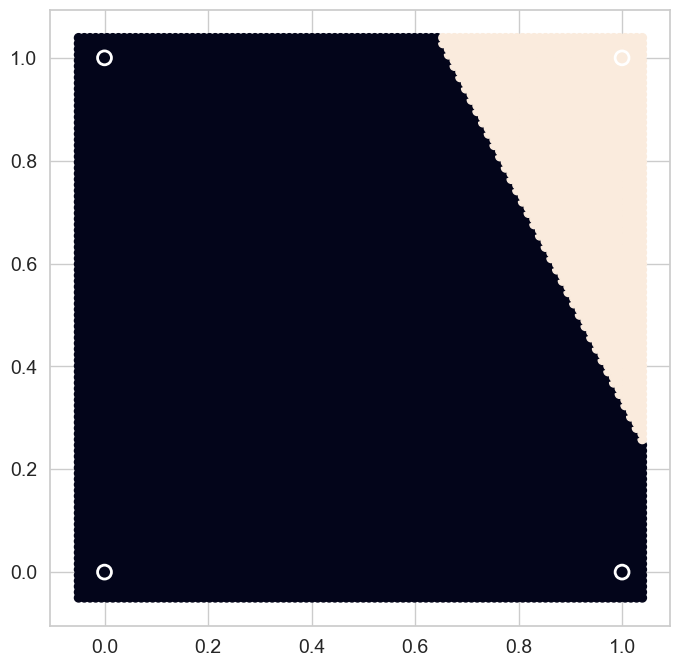

In [3]:
data = torch.tensor([[0., 0.], [1., 1.], [1., 0.], [0., 1.]])
t = torch.tensor([-1., 1., -1., -1.])

p = Perceptron(epoch=100)
p.fit(data, t)

hp.plot_binary(p.predict, data, t)

## Decision surface of a perceptron

- Convergence is guaranteed if 
  - the training data is linearly separable, and
  - $\eta$ is sufficiently small, e.g., $\eta=0.1$
+ Decision surface of a two input ($x_1$ and $x_2$) perceptron: linearly (AND, OR, NAND) and non-linearly (XOR, EQ) separable
+ Perceptrons can represent linearly separable functions AND, OR, NAND, and NOR
+ Any Boolean function can be represented as a network of perceptrons

## Example - binary classification

In [4]:
@interact(fn=['and','or', 'xor'])
def perceptron(fn='and'):
    X = torch.tensor([[0., 0.], [1., 1.], [1., 0.], [0., 1.]])
    y = hp.rescale(hp.switch_fn(fn)(X))

    # train a perceptron
    clf = Perceptron()
    clf.fit(X, y)
    hp.plot_binary(clf.predict, X, y)

interactive(children=(Dropdown(description='fn', options=('and', 'or', 'xor'), value='and'), Output()), _dom_c…

## Adaline

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-adaline.jpg" width="60%"/>
</center>

- ADAptive Linear Neuron (Adaline) was published only few years after Rosenblatt's perceptron
- Can be considered as improvement of the first one, because it allows a learner to determine "how much" it was right or wrong
- Known also as *delta* or *Widrow-Hoff rule* (after its inventors)

## Adaline training rule

- **Idea**: Use the same algorithm to update weights as for perceptron 
- However, instead of $\hat{y}$ we consider $s$ as an output
$$\vec{s}=\vec{X}\vec{w}$$
where
$$s_j = \vec{x}_j\vec{w} = \sum_{i=0}^n x_{ji}w_{i}$$
- The difference $\vec{e}=\vec{t} - \vec{s} = \vec{t} - \vec{X}\vec{w}$ is vector of a real values indicating the classification error for each example
- Let's find the weights $\vec{w}$ that **minimize** the *mean squared error* (MSE) **loss function**
$$ E[\vec{w}] \doteq \frac{1}{n} \vec{e}^T\vec{e} = \frac{1}{n}\sum_{\langle s_i, t_i \rangle \in \langle \vec{s}, \vec{t} \rangle}(t_{i} - s_{i})^{2} $$
where $\vec{t}$ is a set of labels, $\vec{s}$ is a set of predictions and $n$ is the number of observations
   - factor $1/2n$ is often used to simplify the math
- Use the *gradient descent* optimization method

## Gradient

- Update rule
$$ \vec{w}_{new} \leftarrow \vec{w}_{old} + \eta\:\Delta\vec{w} \qquad\text{ where } \qquad\Delta \vec{w} = -\nabla E[\vec{w}] $$

+ That is, for every weight:

$$ \nabla E[\vec{w}] \doteq \left[\frac{\partial E}{\partial w_{0}},
\frac{\partial E}{\partial w_{1}}, \cdots, \frac{\partial E}{\partial
w_{n}}\right] $$


\begin{eqnarray*}
\frac{\partial E}{\partial w_{i}} 
& = & \frac{\partial}{\partial w_{i}} \frac{1}{2n}\sum_{k}(t_{k} - s_{k})^{2} = \frac{1}{2n}\sum_{k}\frac{\partial}{\partial w_{i}} (t_{k} - s_{k})^{2} 
 = \frac{1}{2n}\sum_{k} 2 (t_{k} - s_{k}) \frac{\partial}{\partial w_{i}}(t_{k} - \vec{x}_{k}\vec{w}) \\
& = & \frac{1}{n} \sum_{k} (t_{k} - s_{k}) \frac{\partial}{\partial w_{i}}(t_{k} - \sum_{j}{x}_{kj}{w_j}) = \frac{1}{n}\sum_{k} (t_{k} - s_{k}) (- x_{ki})
\end{eqnarray*}

+ Training rule for AdaLine in the matrix form: 


$$ \nabla_w E[\vec{w}] = \nabla_w \frac{1}{2n} (\vec{t} - \vec{X}\vec{w})^\top(\vec{t} - \vec{X}\vec{w}) = \frac{1}{2n}(2\vec{X}^\top\vec{X}\vec{w} - 2\vec{X}^\top\vec{t})=\frac{1}{n}(\vec{X}^\top\vec{X}\vec{w} - \vec{X}^\top\vec{t})$$

## Stochastic gradient descent

+ **Incremental mode** Gradient Descent: Do until satisfied
    - For each training example $\vec{x}_k \in \vec{X}$:
        - Compute the gradient $\nabla E_{\vec{x}_k}[\vec{w}]$
        - Update weights $\vec{w}_{new} \gets \vec{w}_{old} -\eta \nabla E_{\vec{x}_k}[\vec{w}]$

$$ E_{\vec{X}}[\vec{w}] \doteq  \frac{1}{2}\sum_{k}(t_{k} - s_{k})^{2} ~~~~ \text{vs.} ~~~~ E_{\vec{x}_k}[\vec{w}] \doteq  \frac{1}{2}(t_{k} - s_{k})^{2} $$


+ **Batch mode** Gradient Descent: Do until satisfied
    - For a set of training examples $\vec{D} \subseteq \vec{X}$:
        - Compute the gradient $\nabla E_{\vec{D}}[\vec{w}]$
        - Update weights $\vec{w}_{new} \gets \vec{w}_{old} -\eta \nabla E_{\vec{D}}[\vec{w}]$

<p class="mycomment">Note: <i>Stochastic Gradient Descent</i>
    can approximate <i>Batch Gradient Descent</i> arbitrarily closely if $\eta$ made small enough </p>

In [5]:
class AdaLine(Perceptron):
    def __init__(self, h=0.01, epoch=1000, eps=0.0001):
        super().__init__(h=h, epoch=epoch, eps=eps)

    def _fit(self, X, labels):
        m = 0
        n=X.size()[0]
        for i in range(self.epoch):
            # compute the gradient
            grad = -(1/n)*torch.subtract(torch.linalg.multi_dot([X.T, X, self.w]), 
                                         torch.matmul(X.T, labels).reshape(-1, 1))
            # termination criterion
            if m > 0 and (m - torch.norm(grad)) < self.eps: break
            m = torch.norm(grad)
            self.w += self.h*grad

        print("Epoch {}: grad={}, w={}".format(i, grad.T, self.w.T))

In [6]:
@interact(fn=['and','or', 'xor'])
def perceptron(fn='and'):
    X = torch.tensor([[0., 0.], [1., 1.], [1., 0.], [0., 1.]])
    y = hp.rescale(hp.switch_fn(fn)(X))

    # train a perceptron
    clf = AdaLine()
    clf.fit(X, y)
    hp.plot_binary(clf.predict, X, y)

interactive(children=(Dropdown(description='fn', options=('and', 'or', 'xor'), value='and'), Output()), _dom_c…

## Summary

- Perceptron is the first classification approach based on connectivists ideas
- Adaline is more general and can also be used to train thresholded perceptron units
- Linear unit training rule uses gradient descent
    - Guaranteed to converge to hypothesis with minimum squared error
    - Given sufficiently small learning rate $\eta$
    - Even when training data contains noise
    - Even when training data not separable by $H$

## Sigmoid unit

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-sigmoid.jpg" width="50%"/>
</center>

+ $\sigma(x)$ is the sigmoid function $$ \sigma(x) = \frac{1}{1 + e^{-x}} $$
+ Nice property: $\frac{\partial \sigma}{\partial x} = \sigma(x) (1 - \sigma(x))$
+ We can derive gradient decent rules to train
    - One sigmoid unit
    - *Multilayer networks* of sigmoid units - end-to-end differentiable!

<div class="myalert">However, deriving such rules for arbitrary networks manually is tedious!</div>

## Idea of the backpropagation

- Consider a function $f(x,y) = \frac{1}{2}(x-y)^2$
- Given a substitution $q(x,y)=x-y$ it can be rewritten as $f(q) = \frac{1}{2}q^2$
- Differentiation of this function is done using the **chain rule**
\begin{equation*}
 \frac{\partial f}{\partial x} = \frac{\partial f}{\partial q}\frac{\partial q}{\partial x}
\end{equation*}
- $\frac{\partial f}{\partial q} = q$ and $\frac{\partial q}{\partial x} = 1$, thus $\frac{\partial f}{\partial x} = q = x-y$
- Similarly, $\frac{\partial q}{\partial y} = -1$, therefore, $\frac{\partial f}{\partial y} = -q = y-x$
- As earlier, partial derivatives of $f$ on $x$ and $y$ express the sensitivity of $f$ on these variables
- However, this influence is expressed over the partial derivative $\frac{\partial f}{\partial q}$ for an intermediate (hidden) variable $q$ 

## Computational graphs

- Computation of gradients for complex functions can be hard
- Consider a sigmoid unit with two inputs which is trained on a binary classification problem with the MSE loss $$L(\hat{y},t)=\frac{1}{n}(t-\hat{y})^2$$
  where $\hat{y}=\sigma(s)$ and $s=1\,w_0+x_1 w_1+x_2 w_2$, and $n=2$ for simplicity
  

- The function to optimize it therefore 


$$L(x_1,x_2,t \mid w_0,w_1,w_2)=\frac{1}{2}\left(t-\frac{1}{1+e^{-(w_0+x_1 w_1+x_2 w_2)}}\right)^2$$ 


- Since $x_1, x_2,$ and $t$ are constants provided in the training data, we need to compute a gradient 


$$ \nabla L[\vec{w}] = \left[\frac{\partial L}{\partial w_{0}},
\frac{\partial L}{\partial w_{1}}, \frac{\partial L}{\partial
w_{2}}\right]^\top $$

- This gradient can then be provided to an optimization algorithm, like gradient descent, to find (optimal) weights of a sigmoid unit wrt. given training examples

### Computational graph - Sigmoid unit


<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-sigmoid-small.svg" width="50%"/>
</center>

<div class="myalert">Using the chain rule and computation graphs this process can be significantly simplified</div>

### Computational graph - Sigmoid unit, cont'd

<br/>
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-sigmoid-comp.svg" width="50%"/>
</center>

### Computational graph - Sigmoid unit, cont'd

- Consider an example in which 
   - we provide the first observation $\vec{x}=[1,3,-2]$ with the target classification label $t=0$
   - to the network with the weights $w_0=-1,w_1=2,$ and $w_2=2$ 
   
   
<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-sigmoid-ex.svg" width="60%"/>
</center>

### Computational graph - Sigmoid unit, cont'd

- If we use stochastic gradient descent, then the update is done after presenting each example
  - let learning rate be $\eta = 0.1$
  - the gradient $\nabla L[\vec{w}] = \left[ 0.1437, 0.4312, -0.2875\right]^\top$
  - the update rule
  $$w_{new} \leftarrow \begin{bmatrix}
           -1 \\ 2 \\ 2 
         \end{bmatrix} - 0.1 \begin{bmatrix}
           0.1437 \\ 0.4312 \\ -0.2875
         \end{bmatrix} ~~~ \Rightarrow ~~~ w_{new} = \begin{bmatrix}
           -1.014 \\ 1.9569 \\ 3.0287
         \end{bmatrix}$$
  
  
- The optimization method can start the next iteration with the next example

# Multilayer networks

+ Perceptrons can only express linear decision surfaces
+ Multilayer networks learned by *Backpropagation* can express a variety of non-linear decision surfaces
+ However, multiple layers of linear Adaline neurons can still produce only linear surfaces
+ Perceptrons are hard to use as the discontinuous threshold make is undifferentiable $\Rightarrow$ unsuitable for gradient descent
+ We want new model that has the best properties of both: 
    - output is a non-linear function of its inputs, 
    - output is a differentiable function of its inputs
    - preferably with range $[0,1]$ as perceptron

## Simple multilayer perceptron

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/ann-mlp.jpg" width="60%"/>
</center>

## Expressive capabilities of multilayer ANNs

- Boolean functions:
    - Every Boolean function can be represented by network with single hidden layer
    - But might require a number of hidden units exponential in number of inputs
- Continuous functions:
    - Every bounded continuous function can be approximated with arbitrarily small error, by network with one hidden layer 
    - Any function can be approximated to arbitrary accuracy by a network with two hidden layers

# Layers

- Input (layer) that holds the raw data, e.g., pixel values of an image
- Dense (fully-connected)
  - Same as multi-layered perceptron layers considered above
  - Used to compute class scores
  - Can use various activation functions depending on their application, e.g., ReLU in the hidden layers or softmax in the output layer

## Example: convolutional layer

- Apply 4 filters with dimensions 3x3x3, which are generated from the 3x3 matrices stored in `flts`
- For each filter a raw output image and its rectified version are shown

In [7]:
from torchvision import datasets, transforms
from PIL import Image

to_image = transforms.ToPILImage(mode="RGB")
to_tensor = transforms.ToTensor()

def conv_ex(filters, i=0, intensity=5, stride=1, padding=1, dilation=0):
    img = Image.open('./images/puppy.jpeg')
    f, ax = plt.subplots(1, 3, figsize=(20,5))
    cv = torch.nn.Conv2d(3,3,3, stride=stride, padding=padding, dilation=dilation)
    flt = torch.FloatTensor(filters[i]).repeat((3,3,1,1))
    flt.divide_(intensity)
    cv.bias = torch.nn.Parameter(torch.zeros(3))
    cv.weight =  torch.nn.Parameter(flt)
    x = to_tensor(img)
    conv = cv(x.unsqueeze(0)).detach().squeeze()
    ax[0].imshow(img)
    ax[1].imshow(to_image(conv))
    ax[2].imshow(to_image(F.relu(conv)))
    for a in ax.flatten(): a.axis('off')
    print("{} -> {}".format(x.shape,  conv.shape))
    plt.show()

In [19]:
flts = np.array([
    [[-1,-1,-1],
     [0,0,0],
     [1,1,1]],
    [[-1,0,1],
     [-1,0,1],
     [-1,0,1]],
    [[-1,0,1],[-1,0,1],[-1,0,1]],
    [[0,-1,0],[-1,4,-1],[0,-1,0]],
    [[1/32,1/16,1/32],[1/16,1/8,1/16],[1/32,1/16,1/32]]
])

interact(conv_ex, filters=fixed(flts), i=(0,3,1), intensity=(1,10,1), stride=(1,10,1), padding=(0,5,1), dilation=(1,10,1));

interactive(children=(IntSlider(value=0, description='i', max=3), IntSlider(value=5, description='intensity', …

- **Conv2D**: Computation of the input and output shapes (2D case - 2 equations)
    - $P$ - padding, if image must be expanded with 0s
    - $D$ - dilation, if a filter focuses on adjacent items
    - $K$ - kernel size
    - $S$ - stride, how filter is applied to an input
    - $N$ - number of examples in a batch presented to a layer

## Auxiliary layers

- Pooling
  - Compute maximum/average values of a region of a previous layer
  - Used to perform downsampling, i.e., to reduce spatial size (height, width), and thus reduce the amount of parameters in the network and control overfitting
  - Commonly inserted between convolutional layers

- **MaxPool2D**: extracts a maximum value for each position of a 2D kernel 

\begin{align}
    out(N_i, C_j, h, w) ={} & \max_{m=0, \ldots, K[0]-1} \max_{n=0, \ldots, K[1]-1} \\
                            & \text{input}(N_i, C_j, S[0] \times h + m, S[1] \times w + n)
\end{align}

- Output size is computed as for the convolutional layer
  - Example: MaxPool2D with a $2\times 2$ kernel and stride $2$ results in an output, which is 4 times smaller than the input

## Auxiliary layers

- Flattening
  - Transform multi-dimensional input into single-dimensional
  - Used as a transition layer between, e.g., convolutional and dense layers
- Dropout
  - Regularization layer that is used to prevent the network from overfitting (works only during the training process)
  - Usually placed after a dense layer
  - Signals of neurons from the previous layer are propagated only with some probability $p$

## Loss functions - a small guide

- The loss function is usually defined as $L = \frac{1}{N} \sum_{i=1}^N L_i$, 
where $N$ is a number of observations and $L_i$ are losses measured for $i$-th observation
- Selection of a loss function depends on the problem
- Classification binary or multi-class - assign one class from a set of classes:
  - Output layer: softmax (hierarchical softmax for large number of classes that are organized in a tree)
  - Loss: binary/categorial cross-entropy (default), hinge (SVM - binary classification) or categorial hinge, Kullback-Leibler divergence
-  Multi-label classification (assign a subset of a set of classes):
   - Output layer: sigmoid (marginal probabilities for classes)
   - Loss: sigmoid cross-entropy (default), binary cross-entropy (measured for each class separtely, e.g., by setting a threshold on values output by each sigmoid unit)
- Regression:
  - Output layer: linear activation
  - Loss: mean squared error (default), logarithmic MSE (large values), mean absolute value (many outliers)

## MNIST Example

- MNIST is dataset comprising 60000 handwritten digits
- Each image has 1 channel (grayscale) and is 28x28 pixels

In [9]:
# fast conversion of the data set into pytorch tensors
# transform the PILImage images of range [0, 1] to an extended range
transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.2,), (0.3,))])

cuda_args = {'num_workers': 1, 'pin_memory': True, 'shuffle': True}

dataset1 = datasets.MNIST('../data', train=True, download=True, transform=transform)
dataset2 = datasets.MNIST('../data', train=False, transform=transform)
train_loader = torch.utils.data.DataLoader(dataset1, batch_size=64, **cuda_args)
val_loader = torch.utils.data.DataLoader(dataset2, batch_size=1024, **cuda_args)

In [10]:
def show_images(images, targets, n=6):
    fig = plt.figure()
    for i in range(n):
        plt.subplot(math.ceil(n/3),3,i+1)
        plt.imshow(images[i][0], cmap='gray', interpolation='none')
        plt.title("class: {}".format(targets[i]))
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print('Mean:{} and std:{} of the first image'.format(images[0][0].mean(), images[0][0].std()))

### Image examples

Batch: 0, images: torch.Size([1024, 1, 28, 28]), targets: torch.Size([1024])


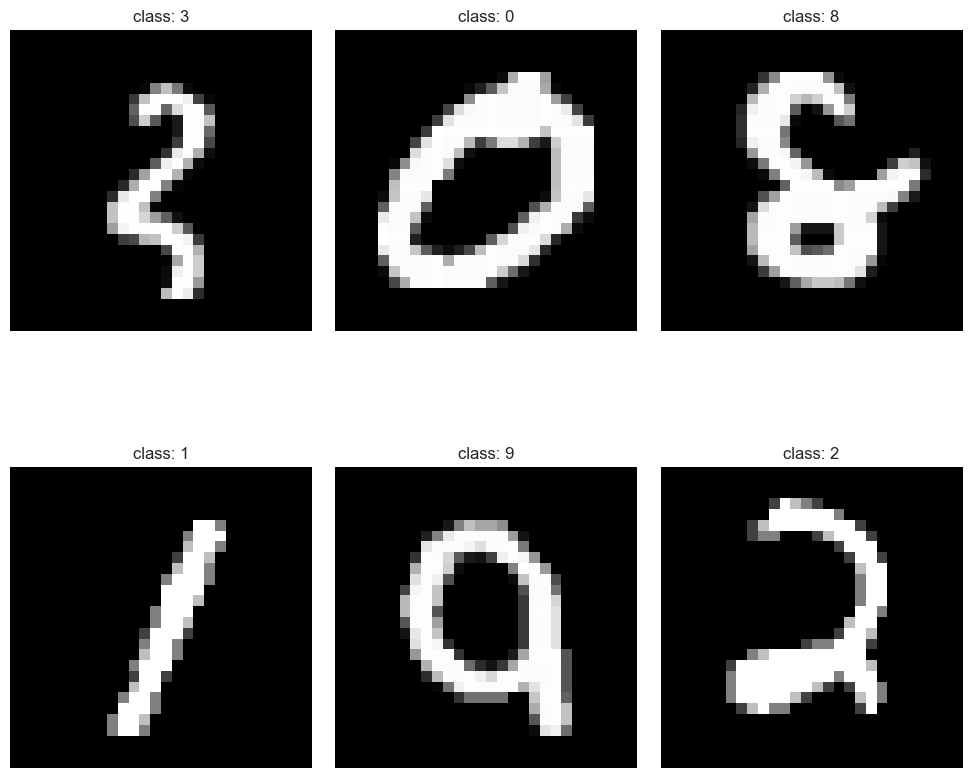

Mean:-0.35979384183883667 and std:0.8754875659942627 of the first image


In [11]:
# get the first batch
val_enum = enumerate(val_loader)
batch_id, (images, targets) = next(val_enum)
print("Batch: {}, images: {}, targets: {}".format(batch_id, images.shape, targets.shape))

# show the first 6 images
show_images(images, targets, 6)

## MNIST - DNN Architecture

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/dnn-mnist.png" width="30%"/>
</center>

### Implementing the architecture

In [12]:
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # input shape 1x28x28, defaults: S = 1, P = 0, D = 1
        # C_in = 1, C_out = 32, K = 3
        self.conv1 = torch.nn.Conv2d(1, 32, 3)
        # H_out = floor(1+(28+2*0-1*(3-1)-1)/1) = 26
        # W_out = ... = 26
        self.conv2 = torch.nn.Conv2d(32, 64, 3)
        self.fc1 = torch.nn.Linear(9216, 128)
        self.dropout = torch.nn.Dropout(0.25)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        # output 26*26*32
        x = self.conv2(x)
        x = F.relu(x)
        # output 24*24*64
        x = F.max_pool2d(x, 2)
        # output = 12*12*64
        x = torch.flatten(x, 1)
        # output = 9216
        x = F.relu(self.fc1(x))
        # output = 128
        x = self.dropout(x)
        return F.log_softmax(self.fc2(x), dim=1)
        
model = Net()
img=torch.randn((1,1,28,28))
print(model(img).exp())
print(model)

tensor([[0.0960, 0.1083, 0.1011, 0.0962, 0.0906, 0.0992, 0.1066, 0.1075, 0.0948,
         0.0996]], grad_fn=<ExpBackward0>)
Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### Training a network

In [13]:
def train(model, device, train_loader, opt, epoch):
    model.train()
    for batch_id, (images, target) in enumerate(train_loader):
        images, target = images.to(device), target.to(device)
        opt.zero_grad()
        output = model(images)
        loss = F.nll_loss(output, target)
        loss.backward()
        opt.step()

### Evaluation function
- Switch off the gradient computation
- Record the results for further visualization

In [14]:
def evaluate(model, device, loader):
    model.eval()
    loss = 0
    correct = 0
    with torch.no_grad():
        for images, target in loader:
            images, target = images.to(device), target.to(device)
            output = model(images)
            loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    loss /= len(loader.dataset)
 
    print('\nEvaluation results: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        loss, correct, len(loader.dataset),
        100. * correct / len(loader.dataset)))
    return loss

### Putting everything together

- Scheduler is used to reduce the learning rate every epoch (just an example)
- Model is trained on the cuda, mps, or cpu device, depending on the hardware

In [20]:
from torch.optim.lr_scheduler import StepLR

dev_name = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Using {} to traing the model".format(dev_name))
device = torch.device(dev_name)

model = Net().to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001)

# Decreases the learning rate of each parameter group by gamma every 1 epoch
scheduler = StepLR(opt, step_size=1, gamma=0.7)
for epoch in range(1, 3):
    train(model, device, train_loader, opt, epoch)
    t_loss = evaluate(model, device, val_loader)
    scheduler.step()

Using mps to traing the model

Evaluation results: Average loss: 0.0536, Accuracy: 9825/10000 (98%)


Evaluation results: Average loss: 0.0305, Accuracy: 9892/10000 (99%)



In [16]:
def split_dataset(model, device, dataloader):
    model.eval()
    correct=[]
    incorrect=[]
    with torch.no_grad():
        for images, target in dataloader:
            d_images, d_target = images.to(device), target.to(device)
            output = model(d_images)
            out_c = output.detach().cpu()
            pred = output.argmax(dim=1, keepdim=True)
            for val,i in zip(pred.eq(d_target.view_as(pred)).cpu(), range(images.size(0))):
                if val:
                    correct.append((images[i], target[i], out_c[i,:]))
                else:
                    incorrect.append((images[i], target[i], out_c[i,:]))
                
    return correct, incorrect

In [21]:
corr, incorr = split_dataset(model, device, val_loader)

@interact(img=(0,10,1))
def plot_results(img=7):
    t = incorr
    f, ax = plt.subplots(1,2, figsize=(10,5))
    ax[0].imshow(t[img][0][0], cmap='gray', interpolation='none')
    ax[0].title.set_text("class: {}".format(t[img][1]))
    ax[1].bar(range(10),torch.exp(t[img][2]))
    ax[1].set_yscale('linear')
    plt.show()

interactive(children=(IntSlider(value=7, description='img', max=10), Output()), _dom_classes=('widget-interact…

# Training ANNs: some remarks

## Regularization in DL

- Regularization is an important method to reduce the risk of overfitting and improve generalization
- These strategies achieve their goal by adding various restrictions/constraints
    - on the model, e.g., constraints on the parameter values
    - on the optimization function, e.g., penalties for too large/small parameter values
    - encoding of a specific prior knowledge, e.g., reflecting the imbalance of the data
    - expressing preferences for models, e.g., simpler models may have better generalization
- In DL, the regularization is usually used to find a good balance between variance and bias

## Early stopping

- Early stopping is an unobtrusive form of regularization
    - Can be used alone or in combination with other methods
    - Required validation set
- Every time validation error improves, we store a copy of the network
- Stop training when the validation error has not decreased by more than some small amount for some number of epochs
    - Training can be continued from this point or restarted 
- Reduction of costs: a well-tuned early stopping can save researchers time and money

## Dataset augmentation & Noise robustness

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/03_DL/images/noise.png" width="60%"/>
</center>

<div class="cite">Goodfellow, Ian J., Jonathon Shlens, and Christian Szegedy. "Explaining and harnessing adversarial examples." arXiv preprint arXiv:1412.6572 (2014)</div>

## Dataset augmentation & Noise robustness

- More examples $\Rightarrow$ better generalization
    - Amount of data is limited in practice
    - Add fake but reasonable data to the dataset
- Some data, like images or sounds, are pretty easy to augment
    - Rotations, cropping, mirroring, pitch shifting, background noise
    - Adversarial examples
- Small amount of noise can be directly injected into inputs
- Noise injection can be applied to the hidden units (Bayesian networks)
    - Model weights are uncertain and 
    - Represent via a probability distribution
    - Select $\vec{w}$ for which small perturbations of $\vec{w}$ have a relatively small influence on the output

## Semi-supervised learning

- Uses unlabeled examples from $P(\rvar{x})$ and labeled examples from $P(\rvar{x}, \rvar{y})$ to predict $\rvar{y}$ from $\rvar{x}$, i.e., estimate $P(\rvar{y} \mid \rvar{x})$
- A network should learn a *representation* $\vec{h}=f(\vec{x})$ such that examples from the same class have similar representations
    - E.g., for any observation $\vec{x}_i$, the Euclidean distance between $\vec{h}_i = f(\vec{x}_i)$ and $\vec{h}_j = f(\vec{x}_j)$ for any $\vec{x}_j$ from the same class must be smaller than between $\vec{h}_i$ and $\vec{h}_k = f(\vec{x}_k)$, for any $\vec{x}_k$ from a different class
- Unsupervised part using examples from $P(\rvar{x})$ is used to provide information on how to group examples in the representation space

## Ensemble methods

- Model averaging is a powerful method to improve the generalization
- Train several models and let them vote for the result
    - If errors of members are uncorrelated, the ensemble performs better than any of its members
    - Use *weak learners* - very simple networks that are not prone to overfitting
- Ensembles can be constructed in various ways

### Bagging

- Bagging decreases variance and reduces the risk of overfitting
- Trains one and the same model on $k$ datasets obtained by sampling with replacement (duplicates are allowed)
- All models are trained *independently* and in parallel

### Boosting 

- Boosting decreases bias, not variance
- Trains the one and the same model focusing it on observations that cannot be explained by previously trained ones - *dependent models*
    - constructs $k$ different datasets by sampling with replacement 
    - sampling is done according to the performance of previously trained models - the worse are the results, the higher is the probability for a sample to be selected